# Data analysis of the behaviors.parquet file

### Import

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [55]:
behaviors = pd.read_parquet("./validation/behaviors.parquet")

display(behaviors.head())
behaviors.info()


,impression_id,article_id,impression_time,read_time,scroll_percentage,device_type,article_ids_inview,article_ids_clicked,user_id,is_sso_user,gender,postcode,age,is_subscriber,session_id,next_read_time,next_scroll_percentage
0,96791,NaN,2023-05-28 04:21:24,9.0,NaN,2,"[9783865, 9784591, 9784679, 9784696, 9784710]",[9784696],22548,False,NaN,NaN,NaN,False,142,72.0,100.0
1,96798,NaN,2023-05-28 04:31:48,46.0,NaN,2,"[9782884, 9783865, 9782726, 9695098, 9782806, ...",[9784281],22548,False,NaN,NaN,NaN,False,143,16.0,28.0
2,96801,NaN,2023-05-28 04:30:17,14.0,NaN,2,"[9784648, 7184889, 9784444, 9781785, 9783405, ...",[9784444],22548,False,NaN,NaN,NaN,False,143,12.0,24.0
3,96808,NaN,2023-05-28 04:27:19,22.0,NaN,2,"[9784607, 9695098, 9784406, 7184889, 9781983]",[9781983],22548,False,NaN,NaN,NaN,False,142,125.0,80.0
4,96810,NaN,2023-05-28 04:29:47,23.0,NaN,2,"[9781983, 7184889, 9784642, 9782108, 9781785, ...",[9784642],22548,False,NaN,NaN,NaN,False,142,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244647 entries, 0 to 244646
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   impression_id           244647 non-null  uint32        
 1   article_id              71302 non-null   float64       
 2   impression_time         244647 non-null  datetime64[us]
 3   read_time               244647 non-null  float32       
 4   scroll_percentage       70481 non-null   float32       
 5   device_type             244647 non-null  int8          
 6   article_ids_inview      244647 non-null  object        
 7   article_ids_clicked     244647 non-null  object        
 8   user_id                 244647 non-null  uint32        
 9   is_sso_user             244647 non-null  bool          
 10  gender                  16311 non-null   float64       
 11  postcode                4508 non-null    float64       
 12  age                     6180 n

In [56]:
missing = behaviors.isna().sum()
missing[missing > 0]

behaviors['impression_time'] = pd.to_datetime(behaviors['impression_time'])

behaviors['num_inview_articles'] = behaviors['article_ids_inview'].apply(lambda x: len(x) if isinstance(x, list) else 0)
behaviors['num_clicked_articles'] = behaviors['article_ids_clicked'].apply(lambda x: len(x) if isinstance(x, list) else 0)


### NaN analysis
NaN ratio for every variables :

In [57]:
behaviors.isna().sum() / len(behaviors)


impression_id             0.000000
article_id                0.708552
impression_time           0.000000
read_time                 0.000000
scroll_percentage         0.711907
device_type               0.000000
article_ids_inview        0.000000
article_ids_clicked       0.000000
user_id                   0.000000
is_sso_user               0.000000
gender                    0.933328
postcode                  0.981573
age                       0.974739
is_subscriber             0.000000
session_id                0.000000
next_read_time            0.027423
next_scroll_percentage    0.121448
num_inview_articles       0.000000
num_clicked_articles      0.000000
dtype: float64

We observe a high proportion of missing values for the following columns but we can explain it : 

article_id (70.86%): These NaNs occur when the impression was recorded on the front page rather than on a specific article. This is expected behavior based on the dataset documentation.

scroll_percentage (71.19%): Since this metric is tied to article views, it’s likely missing when the impression doesn’t correspond to a specific article (article_id is NaN), further reinforcing the front page context.

gender (93.33%), postcode (98.16%), age (97.47%): Just because it's not necessary to give this information therefore people don't do it.

In [58]:
# Summary of main numerical fields
behaviors[['read_time', 'scroll_percentage', 'num_inview_articles', 'num_clicked_articles']].describe()

,read_time,scroll_percentage,num_inview_articles,num_clicked_articles
count,244647.000000,70481.000000,244647.0,244647.0
mean,45.150528,99.560181,0.0,0.0
std,93.804878,4.885912,0.0,0.0
min,0.000000,7.000000,0.0,0.0
25%,11.000000,100.000000,0.0,0.0
50%,21.000000,100.000000,0.0,0.0
75%,46.000000,100.000000,0.0,0.0
max,1799.000000,100.000000,0.0,0.0


Unique users: 15342
Unique sessions: 121837
The type of device used to access the content, such as desktop (1) mobile (2), tablet (3), or unknown (0).


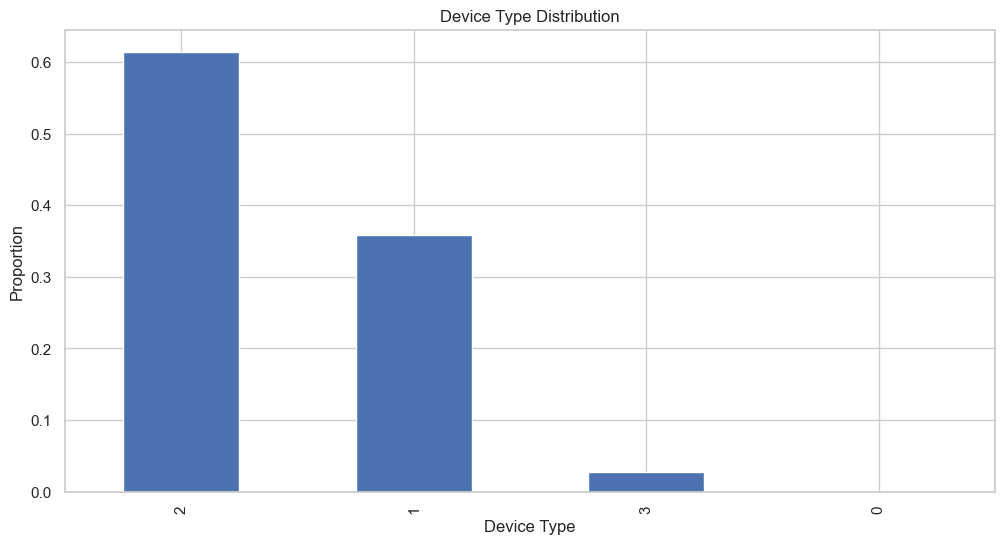

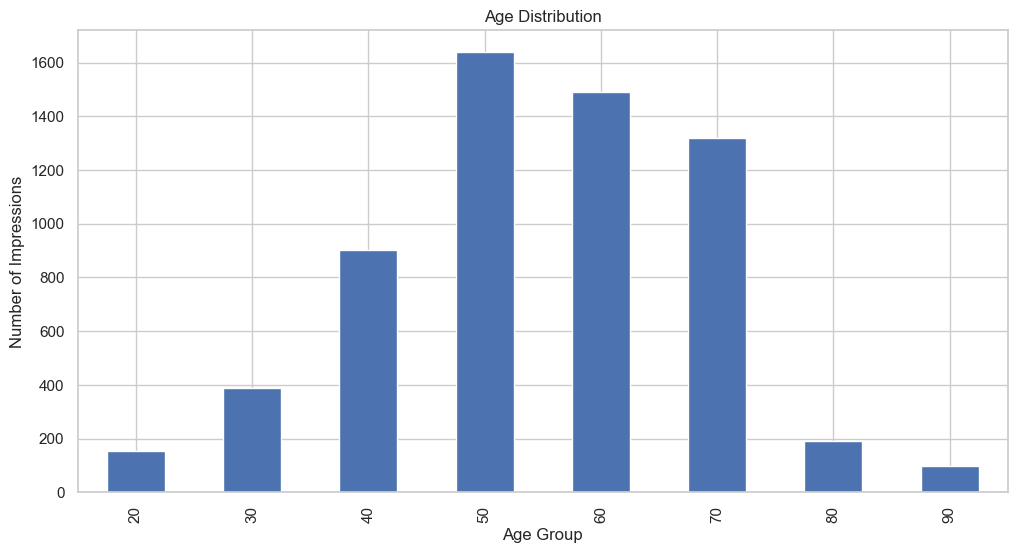

In [59]:
# 👤 Number of unique users and sessions
print(f"Unique users: {behaviors['user_id'].nunique()}")
print(f"Unique sessions: {behaviors['session_id'].nunique()}")



# Device type distribution
behaviors['device_type'].value_counts(normalize=True).plot(kind='bar', title='Device Type Distribution')
print("The type of device used to access the content, such as desktop (1) mobile (2), tablet (3), or unknown (0).")
plt.xlabel('Device Type')
plt.ylabel('Proportion')
plt.show()

# Age distribution
behaviors['age'].dropna().astype(int).value_counts().sort_index().plot(kind='bar', title='Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Impressions')
plt.show()


Most of users use a monile or a desktop to read articles and are betxeen 40 and 70.

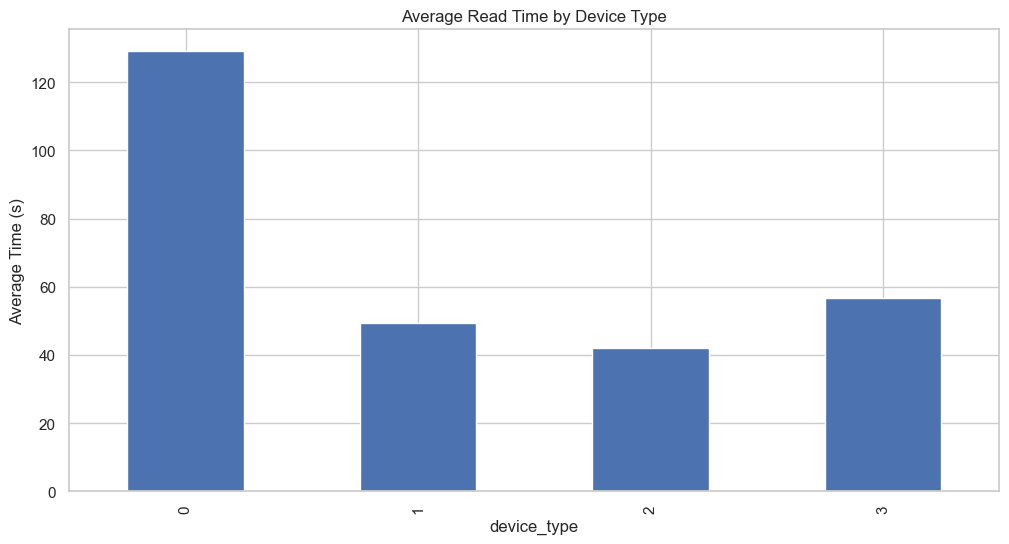

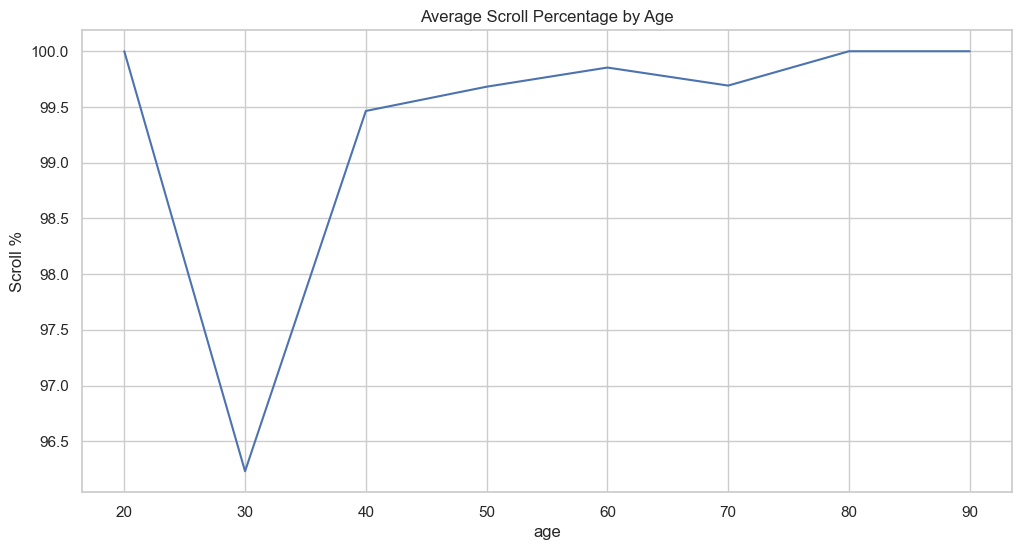

In [60]:
# 📱 Average read_time per device type
behaviors.groupby('device_type')['read_time'].mean().plot(kind='bar', title='Average Read Time by Device Type')
plt.ylabel('Average Time (s)')
plt.show()

# 🔁 Average scroll percentage by age group
behaviors.groupby('age')['scroll_percentage'].mean().plot(kind='line', title='Average Scroll Percentage by Age')
plt.ylabel('Scroll %')
plt.show()


In [61]:
# 📌 Average number of impressions per user
impressions_per_user = behaviors.groupby('user_id')['impression_id'].count()
print(f"Average impressions per user: {impressions_per_user.mean():.2f}")

# ⏱️ Average session duration
session_durations = behaviors.groupby('session_id')['impression_time'].agg(['min', 'max'])
session_durations['duration_sec'] = (session_durations['max'] - session_durations['min']).dt.total_seconds()
print(f"Average session duration: {session_durations['duration_sec'].mean():.2f} s")


Average impressions per user: 15.95
Average session duration: 99.59 s


## Variables relations analysis

### Correlation matrix


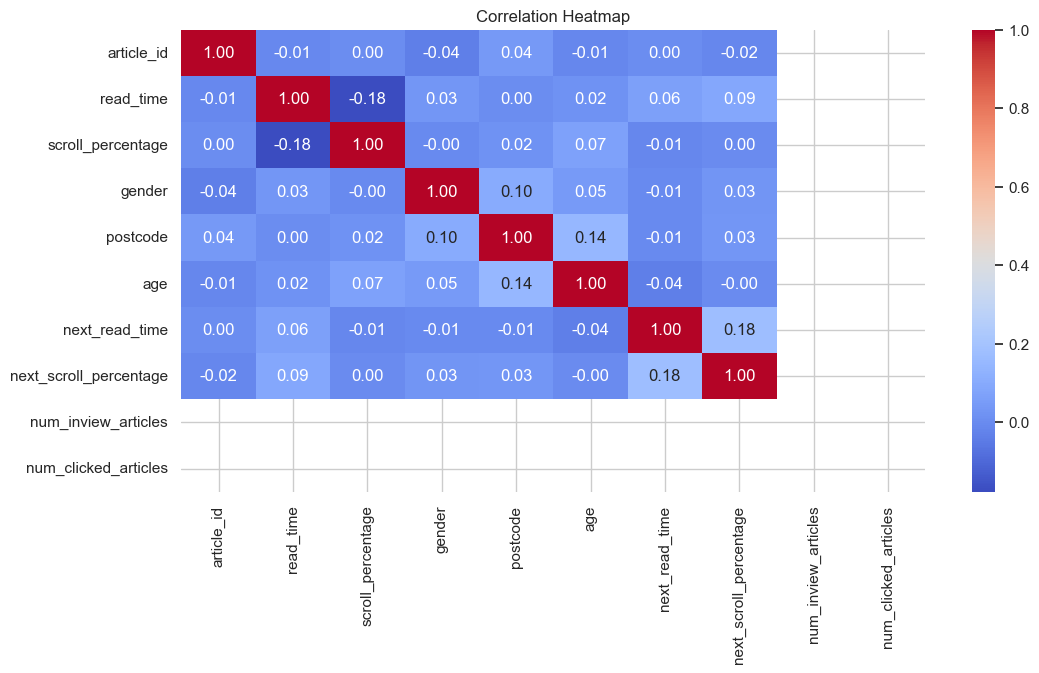

In [62]:

num_cols = behaviors.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).copy()
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


### PCA

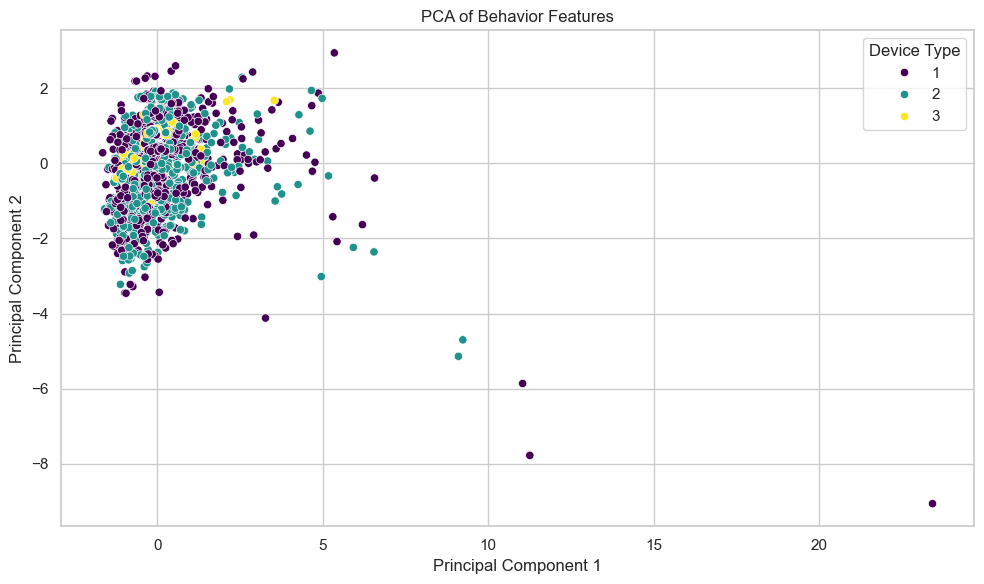

In [63]:
quantitative_cols = [
    "read_time", 
    "scroll_percentage", 
    "next_read_time", 
    "next_scroll_percentage",
    "is_sso_user", 
    "is_subscriber", 
    "age"
]

quantitative_values_df = behaviors[quantitative_cols].dropna()
scaler = StandardScaler()
quantitative_values_scaled = scaler.fit_transform(quantitative_values_df)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(quantitative_values_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['category'] = behaviors.loc[quantitative_values_df.index, 'device_type'].values

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='category', data=pca_df, palette='viridis')
plt.title('PCA of Behavior Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Device Type')
plt.tight_layout()
plt.show()
